# Diagnostics

Before trusting the posterior in the Results notebook, I ask whether the
sampler converged and explored well.

This notebook reads the run saved by Results and computes everything from scratch with `toynuts.diagnostics`, no external library.
We look at the summary table, traces and chain posteriors,
then split-Rhat, the bulk and tail effective sample sizes, divergences, the
tree depth and finally the energy diagnostic E-BFMI.

## Load the saved run

Run `01_results.ipynb` first; this cell only reads what it wrote.

In [1]:
import sys
from pathlib import Path

# The project root is the directory holding src/toynuts. From it we put the
# package on the path (no install needed) and fix one run directory the three
# notebooks share: Results writes it, Diagnostics and Calibration read it.
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "toynuts").is_dir()),
    Path.cwd(),
)
if not any((Path(p) / "toynuts").is_dir() for p in sys.path):
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
RUN_DIR = PROJECT_ROOT / "outputs" / "notebook_run"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from toynuts.io import read_run
from toynuts.diagnostics import (
    summary, split_rhat, ess_bulk, ess_tail,
    divergence_summary, tree_depth_summary, ebfmi,
    autocorr, chain_ranks, diagnostic_report,
)
from toynuts import plotting as P

plt.rcParams["figure.dpi"] = 110

if not RUN_DIR.exists():
    raise FileNotFoundError(f"no saved run at {RUN_DIR}; run 01_results.ipynb first")
draws, stats, run_config = read_run(RUN_DIR)
params = ["beta_0", "beta_1", "sigma"]
chains = sorted(draws["chain"].unique())
# Energy as (n_chains, n_draws) for E-BFMI, and the configured depth cap.
energy = stats.pivot(index="chain", columns="draw", values="energy").to_numpy()
max_tree_depth = int(run_config["max_tree_depth"].iloc[0])
print(f"loaded {len(chains)} chains x {draws['draw'].nunique()} draws from {RUN_DIR.name}")

loaded 4 chains x 2000 draws from notebook_run


## The summary table

One row per parameter with the posterior mean and standard deviation, split-Rhat
and the bulk and tail effective sample sizes. Each diagnostic cell is shaded
green, amber or red against the workflow thresholds, a reserved status palette
that the rest of the notebook unpacks.

In [2]:
report = diagnostic_report(draws, stats)
P.style_table(report).format(
    {"mean": "{:.3f}", "sd": "{:.3f}", "r_hat": "{:.4f}",
     "ess_bulk": "{:.0f}", "ess_tail": "{:.0f}"})

,mean,sd,r_hat,ess_bulk,ess_tail
beta_0,1.025,0.113,1.0005,5201,4292
beta_1,2.015,0.081,0.9999,6414,5369
sigma,1.000,0.075,1.0002,5464,5165


## Trace plots and the chain posteriors

A converged run looks like a fuzzy horizontal band with no drift or sticking,
and the four per-chain densities on the right should lie on top of one
another. Disagreement between chains is what split-Rhat then quantifies.

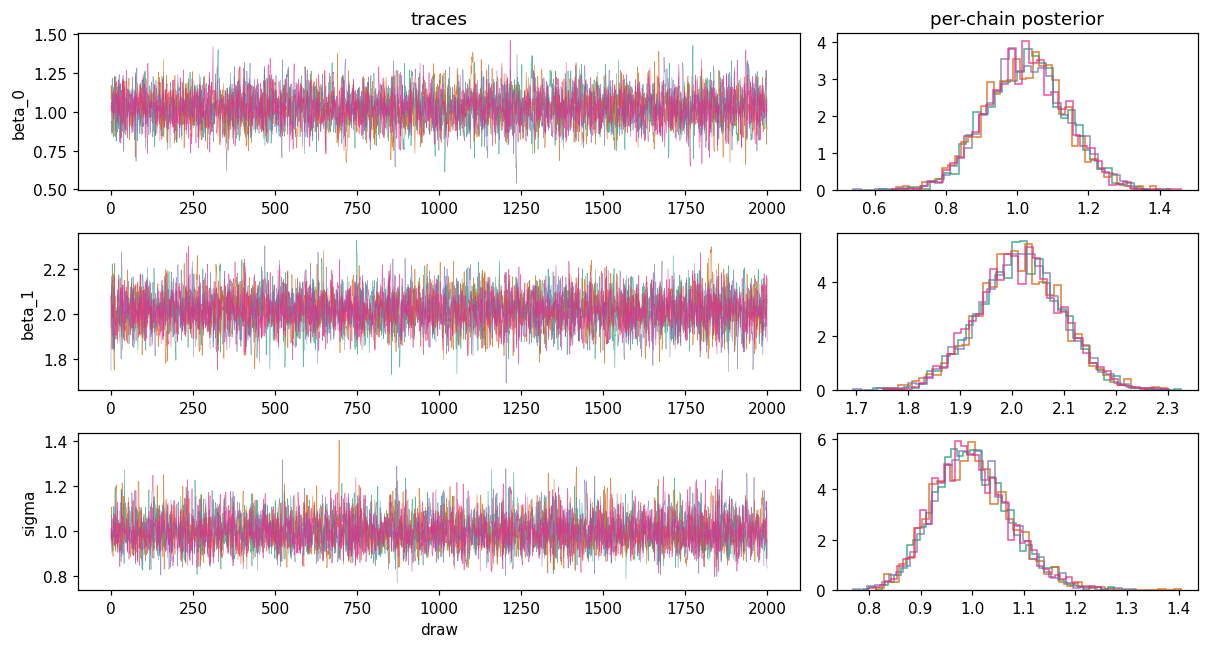

In [3]:
fig, axes = plt.subplots(len(params), 2, figsize=(11, 6),
                         gridspec_kw={"width_ratios": [2, 1]})
for row, p in enumerate(params):
    for c in chains:
        colour = P.CHAIN_COLOURS[c % len(P.CHAIN_COLOURS)]
        d = draws[draws.chain == c]
        axes[row, 0].plot(d["draw"], d[p], lw=0.4, alpha=0.7, color=colour)
        axes[row, 1].hist(d[p], bins=40, density=True, histtype="step", alpha=0.8, color=colour)
    axes[row, 0].set_ylabel(p)
axes[0, 0].set_title("traces")
axes[0, 1].set_title("per-chain posterior")
axes[-1, 0].set_xlabel("draw")
fig.tight_layout()
plt.show()

## Rank plots

Pool all draws, rank them, then histogram the ranks within each chain. Under
convergence each chain's ranks are uniform, so the bars sit flat; rank plots pair
with the rank-normalised Rhat and catch between-chain discrepancies more reliably
than the raw trace.

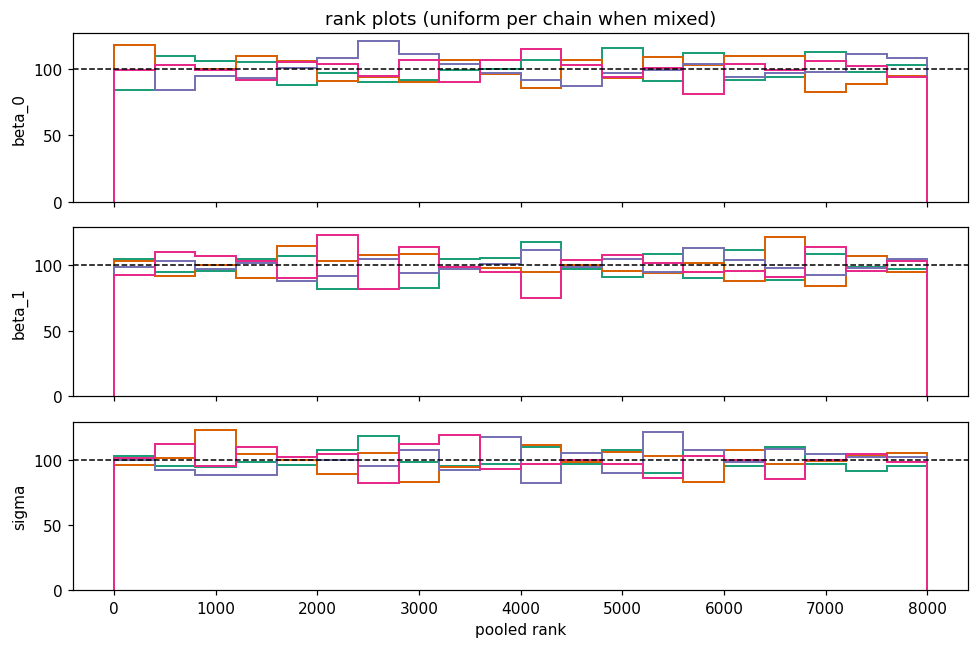

In [4]:
fig, axes = plt.subplots(len(params), 1, figsize=(9, 6), sharex=True)
nbins = 20
for ax, p in zip(axes, params):
    ranks = chain_ranks(draws, p)
    edges = np.linspace(ranks.min(), ranks.max(), nbins + 1)
    for c in chains:
        colour = P.CHAIN_COLOURS[c % len(P.CHAIN_COLOURS)]
        ax.hist(ranks[c], bins=edges, histtype="step", lw=1.3, color=colour)
    ax.axhline(ranks.shape[1] / nbins, color="k", ls="--", lw=1)
    ax.set_ylabel(p)
axes[0].set_title("rank plots (uniform per chain when mixed)")
axes[-1].set_xlabel("pooled rank")
fig.tight_layout()
plt.show()

## Autocorrelation

Autocorrelation by chain, a corroboration of the effective sample size. A chain
that mixes well decays to zero within a few lags.

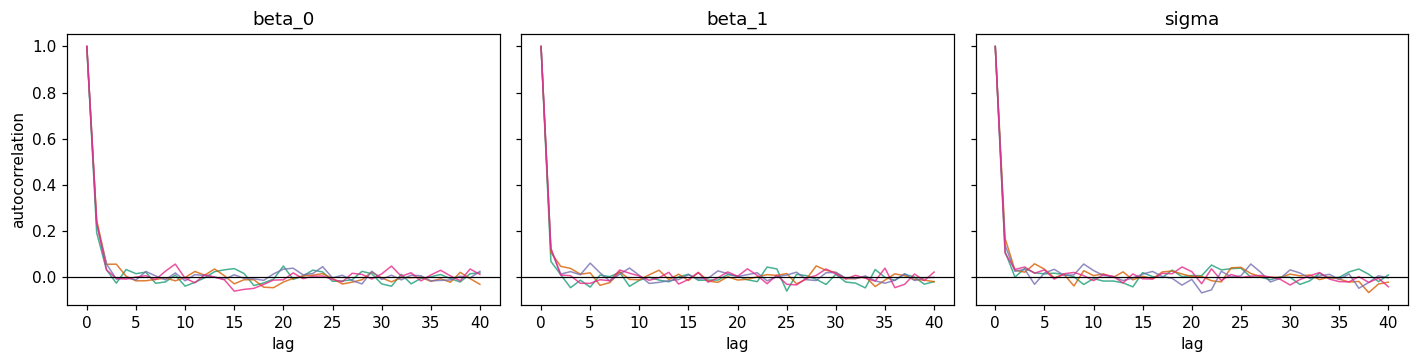

In [5]:
acf = autocorr(draws, max_lag=40)
fig, axes = plt.subplots(1, len(params), figsize=(13, 3.4), sharey=True)
for ax, p in zip(axes, params):
    sub = acf[acf["param"] == p]
    for c in chains:
        colour = P.CHAIN_COLOURS[c % len(P.CHAIN_COLOURS)]
        s = sub[sub["chain"] == c]
        ax.plot(s["lag"], s["acf"], lw=1.0, alpha=0.8, color=colour)
    ax.axhline(0.0, color="k", lw=0.8)
    ax.set(title=p, xlabel="lag")
axes[0].set_ylabel("autocorrelation")
fig.tight_layout()
plt.show()

## R-hat

Rank-normalised split-Rhat compares the variance within chains to the
variance between them, after splitting each chain in half to catch slow
drift. Values at or below 1.01 are the usual pass.

In [6]:
rhat = split_rhat(draws)
print(rhat.round(4).to_string())
print("\nall at or below 1.01:", bool((rhat <= 1.01).all()))

beta_0    1.0005
beta_1    0.9999
sigma     1.0002

all at or below 1.01: True


## Effective sample size: bulk and tail

Autocorrelation means the draws carry less information than their count
suggests. Bulk ESS governs the centre of the distribution and tail ESS the
extremes; both should be comfortably into the thousands here, a large
fraction of the raw draw count.

total draws: 8000
        ess_bulk  ess_tail  bulk_per_draw
beta_0    5201.0    4292.0           0.65
beta_1    6414.0    5369.0           0.80
sigma     5464.0    5165.0           0.68


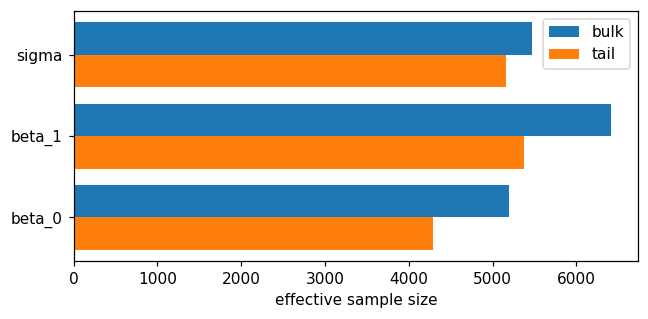

In [7]:
total = len(draws)
ess = pd.DataFrame({"ess_bulk": ess_bulk(draws), "ess_tail": ess_tail(draws)})
ess["bulk_per_draw"] = ess["ess_bulk"] / total
print(f"total draws: {total}")
print(ess.round({"ess_bulk": 0, "ess_tail": 0, "bulk_per_draw": 2}).to_string())

fig, ax = plt.subplots(figsize=(6, 3))
pos = np.arange(len(params))
ax.barh(pos + 0.2, ess["ess_bulk"], height=0.4, color="C0", label="bulk")
ax.barh(pos - 0.2, ess["ess_tail"], height=0.4, color="C1", label="tail")
ax.set_yticks(pos)
ax.set_yticklabels(params)
ax.set_xlabel("effective sample size")
ax.legend()
fig.tight_layout()
plt.show()

## Divergences

A divergence is the integrator's warning that the step size was too large for
the local curvature, leaving part of the posterior unreachable. They tend to
cluster in awkward regions, so the usual check is to mark them on a scatter of
the draws. With the matched metric there are none here.

divergences    0.0
rate           0.0


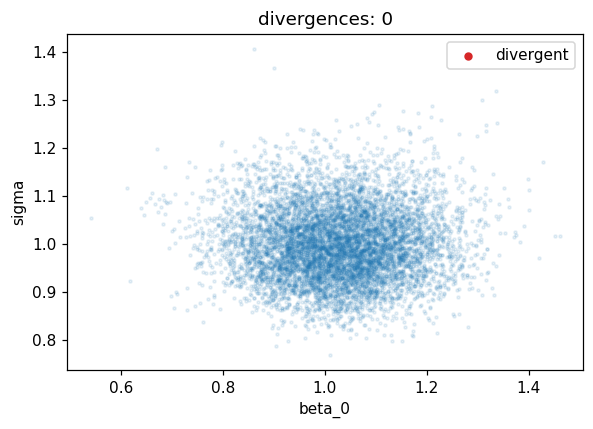

In [8]:
print(divergence_summary(stats).to_string())

div = stats["divergent"].to_numpy()
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(draws["beta_0"], draws["sigma"], s=4, alpha=0.1, color="C0")
ax.scatter(draws[div]["beta_0"], draws[div]["sigma"], s=20, color="C3", label="divergent")
ax.set(xlabel="beta_0", ylabel="sigma", title=f"divergences: {int(div.sum())}")
ax.legend()
fig.tight_layout()
plt.show()

## Maximum tree depth

NUTS doubles its trajectory until a U-turn, capped at `max_tree_depth`. If the
depth saturates at the cap the sampler is being cut off before it turns and
the cap should rise. Here the depth sits well below it.

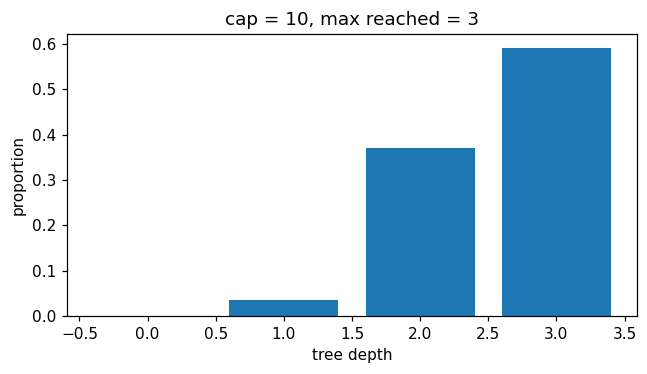

In [9]:
depth = tree_depth_summary(stats)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(depth.index.astype(int), depth.to_numpy(), color="C0")
ax.set(xlabel="tree depth", ylabel="proportion",
       title=f"cap = {max_tree_depth}, max reached = {int(stats['tree_depth'].max())}")
fig.tight_layout()
plt.show()

## E-BFMI (energy)

The energy diagnostic asks whether momentum refreshment explores the energy
distribution efficiently.

The check is on spread, not shape: the energy
transition distribution should be about as wide as the marginal energy
distribution.

When the transitions are much narrower the sampler inches along
the energy axis and mixes slowly in the tails, which E-BFMI condenses into a
number. The two curves need not match in shape: in few dimensions the marginal energy is right-skewed while the transitions are near-symmetric, so they share a width but lean opposite ways.

E-BFMI per chain: [0.976 0.981 0.927 1.029]
all above 0.3: True


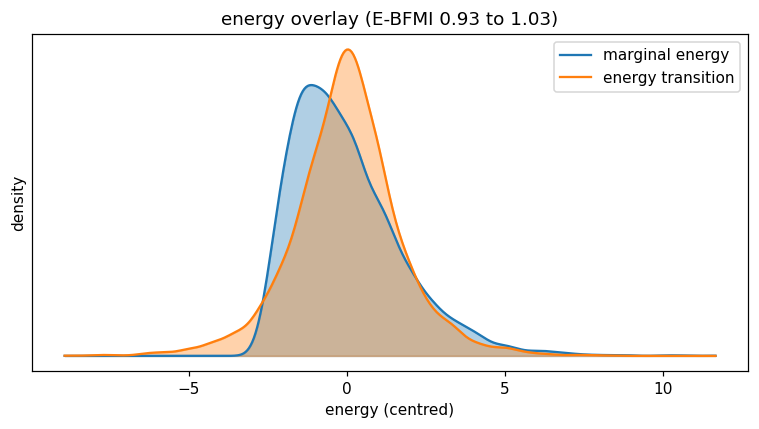

In [10]:
bfmi = ebfmi(energy)
print("E-BFMI per chain:", bfmi.round(3).to_numpy())
print("all above 0.3:", bool((bfmi > 0.3).all()))

# Pool the per-chain marginal energy (centred) and the energy transitions.
marginal, transitions = [], []
for c in chains:
    e = stats[stats.chain == c].sort_values("draw")["energy"].to_numpy()
    marginal.append(e - e.mean())
    transitions.append(np.diff(e))
marginal = np.concatenate(marginal)
transitions = np.concatenate(transitions)

grid = np.linspace(min(marginal.min(), transitions.min()),
                   max(marginal.max(), transitions.max()), 400)
fig, ax = plt.subplots(figsize=(7, 4))
for vals, label, color in [(marginal, "marginal energy", "C0"),
                           (transitions, "energy transition", "C1")]:
    density = gaussian_kde(vals)(grid)
    ax.fill_between(grid, density, color=color, alpha=0.35)
    ax.plot(grid, density, color=color, lw=1.5, label=label)
ax.set(xlabel="energy (centred)", ylabel="density", yticks=[],
       title=f"energy overlay (E-BFMI {bfmi.min():.2f} to {bfmi.max():.2f})")
ax.legend()
fig.tight_layout()
plt.show()

## Verdict

Split-Rhat at 1.00, effective sample sizes in the thousands, no divergences,
tree depth below the cap and E-BFMI near one: the chains have converged and
mixed, so the posterior summaries in the Results notebook can be trusted.